# Delta-V LoRA Perturbation Analysis

This notebook analyzes the **LoRA Delta-V model**: V_net's weight matrices are adapted
via low-rank residual matrices (A·B) to capture the perturbation potential.

Instead of adding a separate `delta_V_net`, LoRA modifies V_net's internal computation:
`W_effective = W_frozen + (alpha/rank) * A @ B`

ΔV is extracted by comparing V_net output with vs without LoRA contribution.

In [37]:
# Standard library imports
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

# Auto-detect project root
_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pytorch_lightning import seed_everything
from pysr import PySRRegressor

# Import BOTH model classes
from examples.pend_lag_cavae_trainer import Model  # original (unperturbed)
from examples.pend_delta_v_lora_trainer import DeltaVLoRAModel  # LoRA delta-V
from examples.pend_delta_v_lora_latent_trainer import DeltaVLoRALatentModel  # LoRA + latent
from lag_caVAE.lag_lora_v import LoRALinear  # for temporarily disabling LoRA

seed_everything(0)
%matplotlib inline

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


## Configuration

In [46]:
# ============================================================
# CONFIGURATION
# ============================================================

from numpy import poly

CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_DELTA_V     = '_ckpt_epoch_624.ckpt'   # <-- update with your trained checkpoint name

ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')
ckpt = torch.load(os.path.join(ckpt_dir, CKPT_DELTA_V), map_location='cpu', weights_only=False)
print('T_pred:', ckpt['checkpoint_callback_best_model_score'])

# ============================================================
# PERTURBATION CONFIG — Gaussian (local bump)
# V_pert = epsilon * exp(-(theta - theta_0)^2 / sigma^2)
# da     = epsilon * 2*(theta-theta_0)/sigma^2 * exp(-(theta-theta_0)^2/sigma^2)
# ============================================================
EPSILON = 10.0   # amplitude
THETA_0 = 0.0   # center (radians)
SIGMA   = 1.0   # width  (radians)

perturbation_config = dict(
    name        = f"Gaussian (eps={EPSILON}, theta0={THETA_0}, sigma={SIGMA})",
    da_formula  = f"{EPSILON} * 2*(theta-{THETA_0})/({SIGMA}^2) * exp(-(theta-{THETA_0})^2/{SIGMA}^2)",
    dV_formula  = f"M * {EPSILON} * exp(-(theta-{THETA_0})^2/{SIGMA}^2)",
    true_da     = lambda theta, M: (
        EPSILON * 2*(theta - THETA_0)/SIGMA**2
        * np.exp(-(theta - THETA_0)**2 / SIGMA**2)
    ),
    true_dV_raw = lambda theta, M: (
        M * EPSILON * np.exp(-(theta - THETA_0)**2 / SIGMA**2)
    ),
    pysr_unary      = ['exp'],
    pysr_binary     = ['+', '-', '*'],
    sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True),
    sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True),
    poly_deg_da = 5,
    poly_deg_dV = 6,
)

# Short alias
PC = perturbation_config

# Sampling
N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi

# PySR hyperparameters
PYSR_NITERATIONS = 100
PYSR_MAXSIZE     = 25

# Plot settings
DPI = 600

print(f"Perturbation: {PC['name']}")
print(f"  da = {PC['da_formula']}")
print(f"  dV = {PC['dV_formula']}")


T_pred: tensor(13.1710)
Perturbation: Gaussian (eps=10.0, theta0=0.0, sigma=1.0)
  da = 10.0 * 2*(theta-0.0)/(1.0^2) * exp(-(theta-0.0)^2/1.0^2)
  dV = M * 10.0 * exp(-(theta-0.0)^2/1.0^2)


## 1. Load Models

Load the unperturbed base model (for phase offset calibration) and the Delta-V model.

In [47]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

# Load unperturbed model (for calibration)
model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()
print("Unperturbed model loaded.")

# Load LoRA Delta-V model — need weights_only=False for old PL checkpoints
import pytorch_lightning as pl
_orig_torch_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_load

# Inspect checkpoint hyperparameters to pick the right class
ckpt_path = os.path.join(ckpt_dir, CKPT_DELTA_V)
ckpt_data = torch.load(ckpt_path, map_location='cpu')
hp = ckpt_data.get('hyper_parameters', {})
has_latent = 'latent_alpha' in hp
del ckpt_data  # free memory

if has_latent:
    model_delta_v = DeltaVLoRALatentModel.load_from_checkpoint(ckpt_path, map_location='cpu')
    print("Loaded as DeltaVLoRALatentModel (LoRA + latent loss)")
else:
    model_delta_v = DeltaVLoRAModel.load_from_checkpoint(ckpt_path, map_location='cpu')
    print("Loaded as DeltaVLoRAModel (LoRA only)")
model_delta_v.eval()

torch.load = _orig_torch_load  # restore original

# Verify LoRA layers exist
n_lora = sum(p.numel() for n, p in model_delta_v.named_parameters() if 'lora_' in n)
print(f"LoRA Delta-V model loaded.")
print(f"  LoRA parameters: {n_lora}")
for name, layer in model_delta_v.ode.V_net.named_modules():
    if isinstance(layer, LoRALinear):
        print(f"  {name}: rank={layer.rank}, in={layer.in_features}, out={layer.out_features}")

Unperturbed model loaded.
Loaded as DeltaVLoRAModel (LoRA only)
LoRA Delta-V model loaded.
  LoRA parameters: 1624
  linear1: rank=8, in=2, out=50
  linear2: rank=8, in=50, out=50
  linear3: rank=8, in=50, out=1


## 2. Helper Functions

In [48]:
def extract_physics(model, theta_np):
    """Extract V(φ), M(φ), dV/dφ, and acceleration a(φ) from a trained model."""
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV_dtheta = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV_dtheta
    
    return {
        'theta': theta_np,
        'V':         V.detach().numpy().flatten(),
        'M':         M.detach().numpy().flatten(),
        'dVdtheta':  dV_dtheta.detach().numpy().flatten(),
        'acc':       acc.detach().numpy().flatten(),
    }


def extract_delta_v_physics(model, theta_np):
    """
    Extract LoRA-induced perturbation from V_net.
    
    Computes delta_V by running V_net twice:
    1. With LoRA enabled (V_total = V_net with W + alpha/r * A@B)
    2. With LoRA disabled (V_base = V_net with W only)
    Then delta_V = V_total - V_base.
    """
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()

    # 1. V_total: V_net with LoRA enabled (normal forward pass)
    V_total = model.ode.V_net(cos_sin)
    dV_total_dtheta = torch.autograd.grad(
        V_total.sum(), theta, retain_graph=True, create_graph=False
    )[0]

    # 2. V_base: temporarily disable LoRA by zeroing scaling
    saved_scalings = {}
    for name, module in model.ode.V_net.named_modules():
        if isinstance(module, LoRALinear):
            saved_scalings[name] = module.scaling
            module.scaling = 0.0
    
    # Need fresh computation graph for V_base
    theta2 = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q2 = torch.cos(theta2)
    sin_q2 = torch.sin(theta2)
    cos_sin2 = torch.stack((cos_q2, sin_q2), dim=1)
    V_base = model.ode.V_net(cos_sin2)

    # Restore LoRA scaling
    for name, module in model.ode.V_net.named_modules():
        if isinstance(module, LoRALinear):
            module.scaling = saved_scalings[name]
    
    # delta_V = V_total - V_base
    delta_V = V_total.detach() - V_base.detach()

    # Compute d(delta_V)/dtheta from the difference of gradients
    dV_base_dtheta = torch.autograd.grad(
        V_base.sum(), theta2, create_graph=False
    )[0]
    d_delta_V_dtheta = dV_total_dtheta.detach() - dV_base_dtheta.detach()

    total_acc = -(1.0 / M_flat.detach()) * dV_total_dtheta.detach()
    delta_acc = -(1.0 / M_flat.detach()) * d_delta_V_dtheta
    
    return {
        'theta':          theta_np,
        'delta_V':        delta_V.numpy().flatten(),
        'd_delta_V':      d_delta_V_dtheta.numpy().flatten(),
        'delta_acc':      delta_acc.numpy().flatten(),
        'V_base':         V_base.detach().numpy().flatten(),
        'V_total':        V_total.detach().numpy().flatten(),
        'total_acc':      total_acc.numpy().flatten(),
        'M':              M_flat.detach().numpy().flatten(),
    }


def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    """Find phase offset between NN angle φ and physical angle θ_phys."""
    K = 3 * g / (2 * l)
    
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead'
            )
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    
    mse, sign, offset = best
    res_free = minimize(
        lambda p: np.mean((a_unpert - (p[0] * np.sin(sign * (phi + offset))))**2),
        [-K], method='Nelder-Mead'
    )
    amp_fitted = res_free.x[0]
    
    return {
        'offset': offset, 'sign': sign, 'amplitude': amp_fitted,
        'mse': mse, 'expected_amplitude': -K,
    }


def phi_to_theta_phys(phi, calib):
    """Convert NN angle φ to physical angle θ_phys ∈ [-π, π]."""
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi


def run_pysr(X, y, niterations=100, maxsize=20, parsimony=0.005,
             binary_operators=['+', '-', '*'],
             unary_operators=['sin', 'cos'],
             variable_name='theta'):
    """Run PySR symbolic regression. Returns (model, best_idx, expr, pred)."""
    # Only add nested_constraints when trig operators are present
    kwargs = {}
    if 'sin' in unary_operators or 'cos' in unary_operators:
        kwargs['nested_constraints'] = {"sin": {"sin": 0, "cos": 0}, "cos": {"sin": 0, "cos": 0}}
    
    sr = PySRRegressor(
        niterations=niterations,
        binary_operators=binary_operators,
        unary_operators=unary_operators,
        **kwargs,
        denoise=False,
        model_selection='best',
        maxsize=maxsize,
        parsimony=parsimony,
        populations=30,
        population_size=50,
        ncycles_per_iteration=550,
        weight_optimize=0.001,
        adaptive_parsimony_scaling=1000,
        random_state=42,
        procs=4,
        temp_equation_file=True,
    )
    sr.fit(X, y, variable_names=[variable_name])
    
    eqs = sr.equations_
    scores = eqs['score'].values.astype(float)
    best_idx = eqs.index[np.argmax(scores)]
    
    expr = sr.sympy(index=best_idx)
    pred = sr.predict(X, index=best_idx)
    print(f"  Selected complexity {eqs['complexity'].values[np.argmax(scores)]:.0f} (max score)")
    print(f"  Expression: {expr}")
    return sr, best_idx, expr, pred


print("Helper functions defined.")

Helper functions defined.


## 3. Extract Physics & Calibrate Phase Offset

Use the unperturbed model to calibrate the phase offset, then extract
delta_V_net quantities in physical coordinates.

In [49]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

# Extract base physics from unperturbed model (for calibration)
phys_unpert = extract_physics(model_unpert, theta_range)

# Calibrate phase offset
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print("Phase offset calibration:")
print(f"  sign    = {calib['sign']:+.0f}")
print(f"  offset  = {calib['offset']:.4f} rad ({np.degrees(calib['offset']):.1f} deg)")
print(f"  amplitude (fitted) = {calib['amplitude']:.2f}")
print(f"  amplitude (expected) = {calib['expected_amplitude']:.2f}")
print(f"  MSE = {calib['mse']:.4f}")

# Convert to physical coordinates
theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]
theta_gt = theta_phys_sorted  # standard alias

# Extract LoRA delta-V physics
delta_v_phys = extract_delta_v_physics(model_delta_v, theta_range)

# Sort everything to physical coordinates
delta_V_sorted     = delta_v_phys['delta_V'][sort_idx]
delta_V_sorted     = delta_V_sorted - delta_V_sorted[0]  # zero-anchor
delta_acc_sorted   = delta_v_phys['delta_acc'][sort_idx]
d_delta_V_sorted   = delta_v_phys['d_delta_V'][sort_idx]
V_base_sorted      = delta_v_phys['V_base'][sort_idx]
V_total_sorted     = delta_v_phys['V_total'][sort_idx]
total_acc_sorted   = delta_v_phys['total_acc'][sort_idx]
M_sorted           = delta_v_phys['M'][sort_idx]
a_unpert_sorted    = phys_unpert['acc'][sort_idx]

# M_scale: mean of learned mass matrix (needed for ground truth)
M_scale = np.mean(M_sorted)

# Ground truth from config (GENERIC — no hardcoded formulas)
true_delta_a     = PC['true_da'](theta_gt, M_scale)
true_delta_V_raw = PC['true_dV_raw'](theta_gt, M_scale)
true_delta_V     = true_delta_V_raw - true_delta_V_raw[0]  # zero-anchored

print(f"\nM_scale (mean of learned M_net): {M_scale:.4f}")
print(f"Delta-V range: [{delta_V_sorted.min():.4f}, {delta_V_sorted.max():.4f}]")
print(f"Delta-a range: [{delta_acc_sorted.min():.4f}, {delta_acc_sorted.max():.4f}]")

Phase offset calibration:
  sign    = +1
  offset  = 2.2050 rad (126.3 deg)
  amplitude (fitted) = -15.45
  amplitude (expected) = -15.00
  MSE = 0.6618

M_scale (mean of learned M_net): 0.6915
Delta-V range: [-0.8290, 7.3133]
Delta-a range: [-9.2964, 7.1879]


## 4. Overview: Delta-V Network Output vs Ground Truth

Direct comparison of what delta_V_net learned vs. the true perturbation.

In [50]:
# Ground truth already computed in cell above via PC config
from sklearn.metrics import r2_score

# --- True potential in NN scale ---
# From calibration: a = -K_fitted * sin(θ_phys), and a = -(1/M) dV/dθ
# So V_true = -M_scale * |K_fitted| * cos(θ_phys) + offset
K_fitted = abs(calib['amplitude'])
V_true_unpert = -M_scale * K_fitted * np.cos(theta_gt)
V_unpert_sorted = phys_unpert['V'].flatten()[sort_idx]
V_true_unpert += np.mean(V_unpert_sorted) - np.mean(V_true_unpert)  # align offset

V_true_pert = V_true_unpert + PC['true_dV_raw'](theta_gt, M_scale)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=DPI)

# --- Top left: Delta-V (perturbation potential) ---
ax = axes[0, 0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='LoRA ΔV')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential: LoRA ΔV vs Ground Truth')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Top right: Delta-a (perturbation acceleration) ---
ax = axes[0, 1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from LoRA ΔV)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration: LoRA derived vs Ground Truth')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom left: Total V with true V ---
ax = axes[1, 0]
ax.plot(theta_gt, V_unpert_sorted, 'g-', lw=2, label='V_net (unperturbed model)')
ax.plot(theta_gt, V_base_sorted, 'b--', lw=1.5, label='V_net (frozen, in delta-V model)')
ax.plot(theta_gt, V_total_sorted, 'r-', lw=2, label='V_total = V_net + LoRA ΔV')
ax.plot(theta_gt, V_true_unpert, 'g--', lw=2, alpha=0.6, label='True V (unpert)')
ax.plot(theta_gt, V_true_pert, 'm--', lw=2, alpha=0.6, label='True V (pert)')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('V', fontsize=14)
ax.set_title('Potential Energy Comparison')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Bottom right: Total acceleration ---
ax = axes[1, 1]
a_true_base = -K_fitted * np.sin(theta_gt)
a_true_total = a_true_base + true_delta_a
ax.plot(theta_gt, a_unpert_sorted, 'g-', lw=2, label='a (unperturbed NN)')
ax.plot(theta_gt, total_acc_sorted, 'b-', lw=2, label='a_total (delta-V model)')
ax.plot(theta_gt, a_true_base, 'g--', lw=2, alpha=0.6, label='True a (unpert)')
ax.plot(theta_gt, a_true_total, 'm--', lw=2, alpha=0.6, label='True a (pert)')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('a', fontsize=14)
ax.set_title('Total Acceleration Comparison')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

r2_dv = r2_score(true_delta_V, delta_V_sorted)
r2_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"R2 (LoRA ΔV vs true dV): {r2_dv:.4f}")
print(f"R2 (delta_a vs true da):     {r2_da:.4f}")

R2 (LoRA ΔV vs true dV): 0.8902
R2 (delta_a vs true da):     0.9299


In [51]:
# Extended range for full picture
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)
phys_unpert_ext = extract_physics(model_unpert, phi_ext)
dv_phys_ext = extract_delta_v_physics(model_delta_v, phi_ext)

# Convert to theta_phys using same calibration
theta_phys_ext_unwrapped = calib['sign'] * (phi_ext + calib['offset'])
theta_center = calib['sign'] * calib['offset']
theta_phys_ext_unwrapped = theta_phys_ext_unwrapped - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_phys_ext_unwrapped)
theta_ext_sorted = theta_phys_ext_unwrapped[sort_ext]

# Build "perturbed" dict from delta-V model for consistent plotting
phys_pert_ext = {
    'V':   dv_phys_ext['V_total'],
    'M':   dv_phys_ext['M'],
    'acc': dv_phys_ext['total_acc'],
}

# --- True potential in NN scale (clipped to plot range to avoid polynomial blowup) ---
_xlim = 1.5 * np.pi
_mask = (theta_ext_sorted >= -_xlim) & (theta_ext_sorted <= _xlim)
_theta_clip = theta_ext_sorted[_mask]

V_true_unpert_clip = -M_scale * K_fitted * np.cos(_theta_clip)
V_learned_unpert_clip = phys_unpert_ext['V'].flatten()[sort_ext][_mask]
V_true_unpert_clip += np.mean(V_learned_unpert_clip) - np.mean(V_true_unpert_clip)
V_true_pert_clip = V_true_unpert_clip + PC['true_dV_raw'](_theta_clip, M_scale)

a_true_unpert_clip = -K_fitted * np.sin(_theta_clip)
a_true_pert_clip = a_true_unpert_clip + PC['true_da'](_theta_clip, M_scale)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

labels = ['Unperturbed', 'LoRA V_net (V_total)']
colors = ['#377eb8', '#e41a1c']
data_ext = [phys_unpert_ext, phys_pert_ext]

# Row 1: Raw V, M, acc on extended range
for i, (key, ylabel, title) in enumerate([
    ('V',   r'$V(\theta_{\mathrm{phys}})$',          'Potential Energy'),
    ('M',   r'$M(\theta_{\mathrm{phys}})$',          'Mass Matrix'),
    ('acc', r'$\ddot{\theta}$',  r'Acceleration ($\dot{\theta}=0$)'),
]):
    for d, label, c in zip(data_ext, labels, colors):
        axes[0, i].plot(theta_ext_sorted, d[key][sort_ext], color=c, lw=2, label=label, alpha=0.8)
    axes[0, i].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
    axes[0, i].set_ylabel(ylabel, fontsize=14)
    axes[0, i].set_title(title, fontsize=13)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].set_xlim(-1.5*np.pi, 1.5*np.pi)

# Add true V curves (clipped to plot range)
axes[0, 0].plot(_theta_clip, V_true_unpert_clip, 'g--', lw=2, alpha=0.7, label='True V (unpert)')
axes[0, 0].plot(_theta_clip, V_true_pert_clip, 'm--', lw=2, alpha=0.7, label='True V (pert)')
axes[0, 0].legend(fontsize=8)

# Add true acceleration curves (clipped to plot range)
axes[0, 2].plot(_theta_clip, a_true_unpert_clip, 'g--', lw=2, alpha=0.7, label='True a (unpert)')
axes[0, 2].plot(_theta_clip, a_true_pert_clip, 'm--', lw=2, alpha=0.7, label='True a (pert)')
axes[0, 2].legend(fontsize=8)

# Row 2: Perturbation signals on [-pi, pi]
ax = axes[1, 0]
ax.plot(theta_gt, delta_V_sorted, 'purple', lw=2, label=r'$\Delta V$ (LoRA ΔV)')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential (LoRA ΔV)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
M_unpert_sorted = phys_unpert['M'].flatten()[sort_idx]
M_dv_sorted = delta_v_phys['M'][sort_idx]
M_diff = M_dv_sorted - M_unpert_sorted
ax.plot(theta_gt, M_diff, 'purple', lw=2)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M$', fontsize=14)
ax.set_title('Mass Difference (should be ~0, M frozen)', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_gt, delta_acc_sorted, 'purple', lw=2, label=r'$\Delta a$ (LoRA ΔV)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration (from LoRA ΔV)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()

safe_name = PC["name"].replace(" ", "_").replace("*", "x").replace(":", "_").replace(",", "").replace("(", "").replace(")", "")
fig.savefig(os.path.join(PROJECT_ROOT, 'results', 'pend', 'sine_perturbations_final', f'perturbation_{safe_name}.png'), bbox_inches='tight')

plt.show()

print(f"K_fitted = {K_fitted:.4f} (true K = 15.0)")
print("Row 1: Unperturbed vs Delta-V total, with true V and a curves (dashed, clipped to plot range)")
print("Row 2: LoRA ΔV perturbation signal directly")

K_fitted = 15.4497 (true K = 15.0)
Row 1: Unperturbed vs Delta-V total, with true V and a curves (dashed, clipped to plot range)
Row 2: LoRA ΔV perturbation signal directly


## 5. Polynomial Regression on Delta-V Signal

Since delta_V_net directly outputs the perturbation, polynomial regression
should work much better than on the noisy V_pert − V_unpert subtraction.

In [52]:
from numpy.polynomial import polynomial as P

print("=" * 60)
print(f"POLYNOMIAL REGRESSION — {PC['name']}")
print("=" * 60)

# --- Fit delta_a(theta) ---
print(f"\n--- Polynomial fit to delta_a ---")
print(f"True: da = {PC['da_formula']}")

for deg in range(PC['poly_deg_da'], PC['poly_deg_da'] + 3):
    coeffs = np.polyfit(theta_gt, delta_acc_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_acc_sorted - pred)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

# --- Fit delta_V(theta) ---
print(f"\n\n--- Polynomial fit to delta_V ---")
print(f"True: dV = {PC['dV_formula']}")

for deg in range(PC['poly_deg_dV'], PC['poly_deg_dV'] + 3):
    coeffs = np.polyfit(theta_gt, delta_V_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_V_sorted - pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

POLYNOMIAL REGRESSION — Gaussian (eps=10.0, theta0=0.0, sigma=1.0)

--- Polynomial fit to delta_a ---
True: da = 10.0 * 2*(theta-0.0)/(1.0^2) * exp(-(theta-0.0)^2/1.0^2)

  Degree 5 (R2 = 0.868347):
    theta^5: +0.216244
    theta^4: -0.012190
    theta^3: -2.987921
    theta^2: +0.450988
    theta^1: +9.663840
    theta^0: -1.288446

  Degree 6 (R2 = 0.868349):
    theta^6: -0.000269
    theta^5: +0.216247
    theta^4: -0.008562
    theta^3: -2.987947
    theta^2: +0.439051
    theta^1: +9.663880
    theta^0: -1.282835

  Degree 7 (R2 = 0.970425):
    theta^7: -0.051533
    theta^6: +0.000214
    theta^5: +1.037632
    theta^4: -0.014255
    theta^3: -6.671641
    theta^2: +0.455932
    theta^1: +13.703258
    theta^0: -1.289482


--- Polynomial fit to delta_V ---
True: dV = M * 10.0 * exp(-(theta-0.0)^2/1.0^2)

  Degree 6 (R2 = 0.987636):
    theta^6: -0.036311
    theta^5: +0.001199
    theta^4: +0.665492
    theta^3: -0.097160
    theta^2: -3.797402
    theta^1: +0.843214
    thet

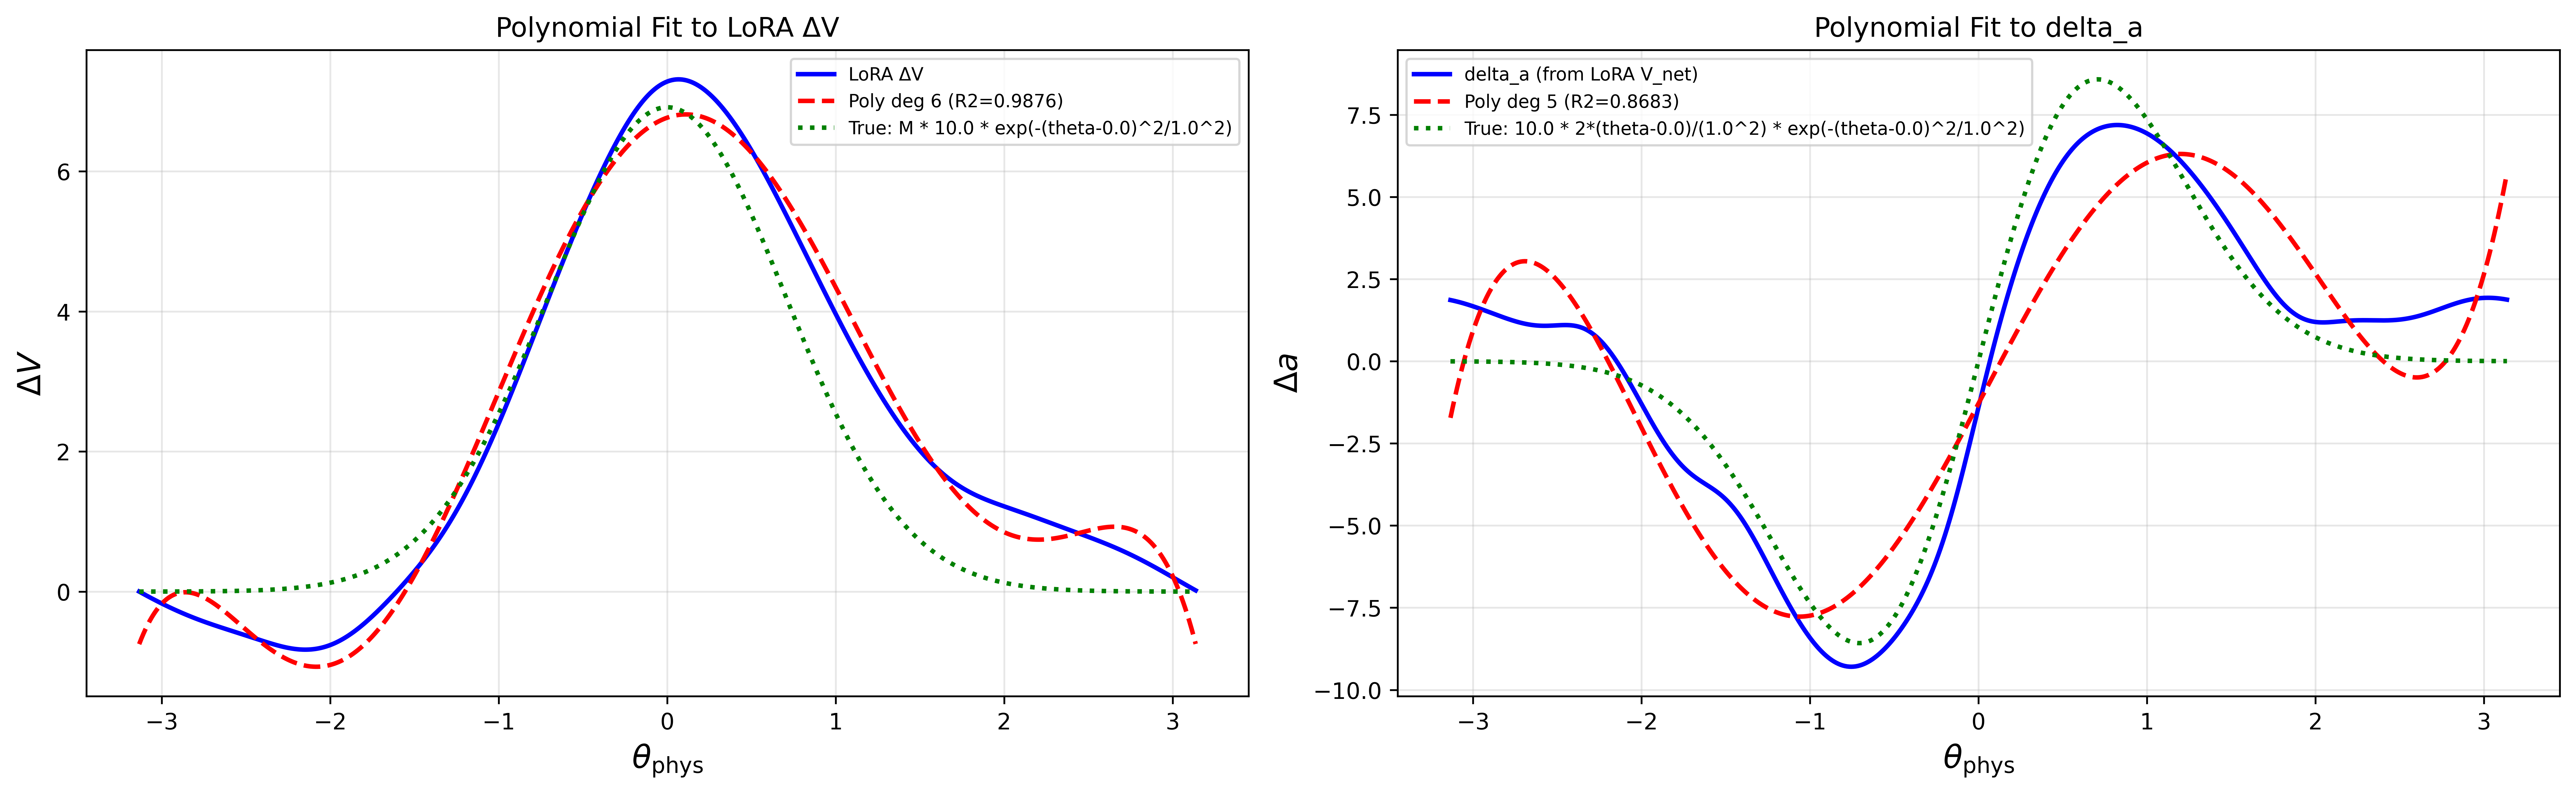

In [53]:
# Plot best polynomial fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# Delta-V
deg_dv = PC['poly_deg_dV']
coeffs_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)
poly_dv = np.polyval(coeffs_dv, theta_gt)
r2_dv = 1 - np.sum((delta_V_sorted - poly_dv)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

ax = axes[0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='LoRA ΔV')
ax.plot(theta_gt, poly_dv, 'r--', lw=2, label=f'Poly deg {deg_dv} (R2={r2_dv:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Polynomial Fit to LoRA ΔV')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Delta-a
deg_da = PC['poly_deg_da']
coeffs_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
poly_da = np.polyval(coeffs_da, theta_gt)
r2_da = 1 - np.sum((delta_acc_sorted - poly_da)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)

ax = axes[1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from LoRA V_net)')
ax.plot(theta_gt, poly_da, 'r--', lw=2, label=f'Poly deg {deg_da} (R2={r2_da:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Polynomial Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SINDy: Sparse Identification of Nonlinear Dynamics

Apply SINDy with polynomial-only library to the Delta-V signal.
Based on notebook 4 findings, we use polynomial-only basis to avoid
poly/trig collinearity issues.

In [54]:
import pysindy as ps

print("=" * 60)
print(f"SINDy — {PC['name']}")
print("=" * 60)

X_sindy = theta_gt.reshape(-1, 1)
thresholds = np.logspace(-3, 0, 20)

# --- SINDy on delta_a ---
print(f"\n--- SINDy on da ---")
print(f"True: da = {PC['da_formula']}")

y_da = delta_acc_sorted.reshape(-1, 1)
lib_da = PC['sindy_library'](ps)

results_da = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=lib_da, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_da, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_da - pred)**2)
    ss_tot = np.sum((y_da - y_da.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_da.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

candidates = [r for r in results_da if r['n_active'] <= 4 and r['r2'] > 0.5]
best_da = max(candidates if candidates else results_da, key=lambda r: r['r2'])

print(f"\nBest SINDy (da): R2 = {best_da['r2']:.4f}, {best_da['n_active']} active terms")
print(f"  Equation: {best_da['equations']}")
print(f"  Threshold: {best_da['threshold']:.4f}")

# Print all active features
feature_names = best_da['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_da['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(


SINDy — Gaussian (eps=10.0, theta0=0.0, sigma=1.0)

--- SINDy on da ---
True: da = 10.0 * 2*(theta-0.0)/(1.0^2) * exp(-(theta-0.0)^2/1.0^2)

Best SINDy (da): R2 = 0.5757, 4 active terms
  Equation: ['-1.195 1 + 4.641 theta + 0.350 theta^2 + -0.616 theta^3']
  Threshold: 0.2336

  Feature                     Coeff
  ----------------------------------
  1                       -1.194925
  theta                    4.641391
  theta^2                  0.349753
  theta^3                 -0.616033


In [55]:
# --- SINDy on delta_V ---
print(f"\n--- SINDy on dV ---")
print(f"True: dV = {PC['dV_formula']}")

y_dv = delta_V_sorted.reshape(-1, 1)
lib_dv = PC['sindy_library_v'](ps)

results_dv = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=lib_dv, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_dv, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_dv - pred)**2)
    ss_tot = np.sum((y_dv - y_dv.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_dv.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

candidates = [r for r in results_dv if r['n_active'] <= 5 and r['r2'] > 0.5]
best_dv = max(candidates if candidates else results_dv, key=lambda r: r['r2'])

print(f"\nBest SINDy (dV): R2 = {best_dv['r2']:.4f}, {best_dv['n_active']} active terms")
print(f"  Equation: {best_dv['equations']}")
print(f"  Threshold: {best_dv['threshold']:.4f}")

feature_names = best_dv['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_dv['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")


--- SINDy on dV ---
True: dV = M * 10.0 * exp(-(theta-0.0)^2/1.0^2)

Best SINDy (dV): R2 = 0.9226, 5 active terms
  Equation: ['6.010 1 + 0.819 theta + -2.189 theta^2 + -0.085 theta^3 + 0.177 theta^4']
  Threshold: 0.0379

  Feature                     Coeff
  ----------------------------------
  1                        6.009988
  theta                    0.818862
  theta^2                 -2.188919
  theta^3                 -0.084708
  theta^4                  0.176731


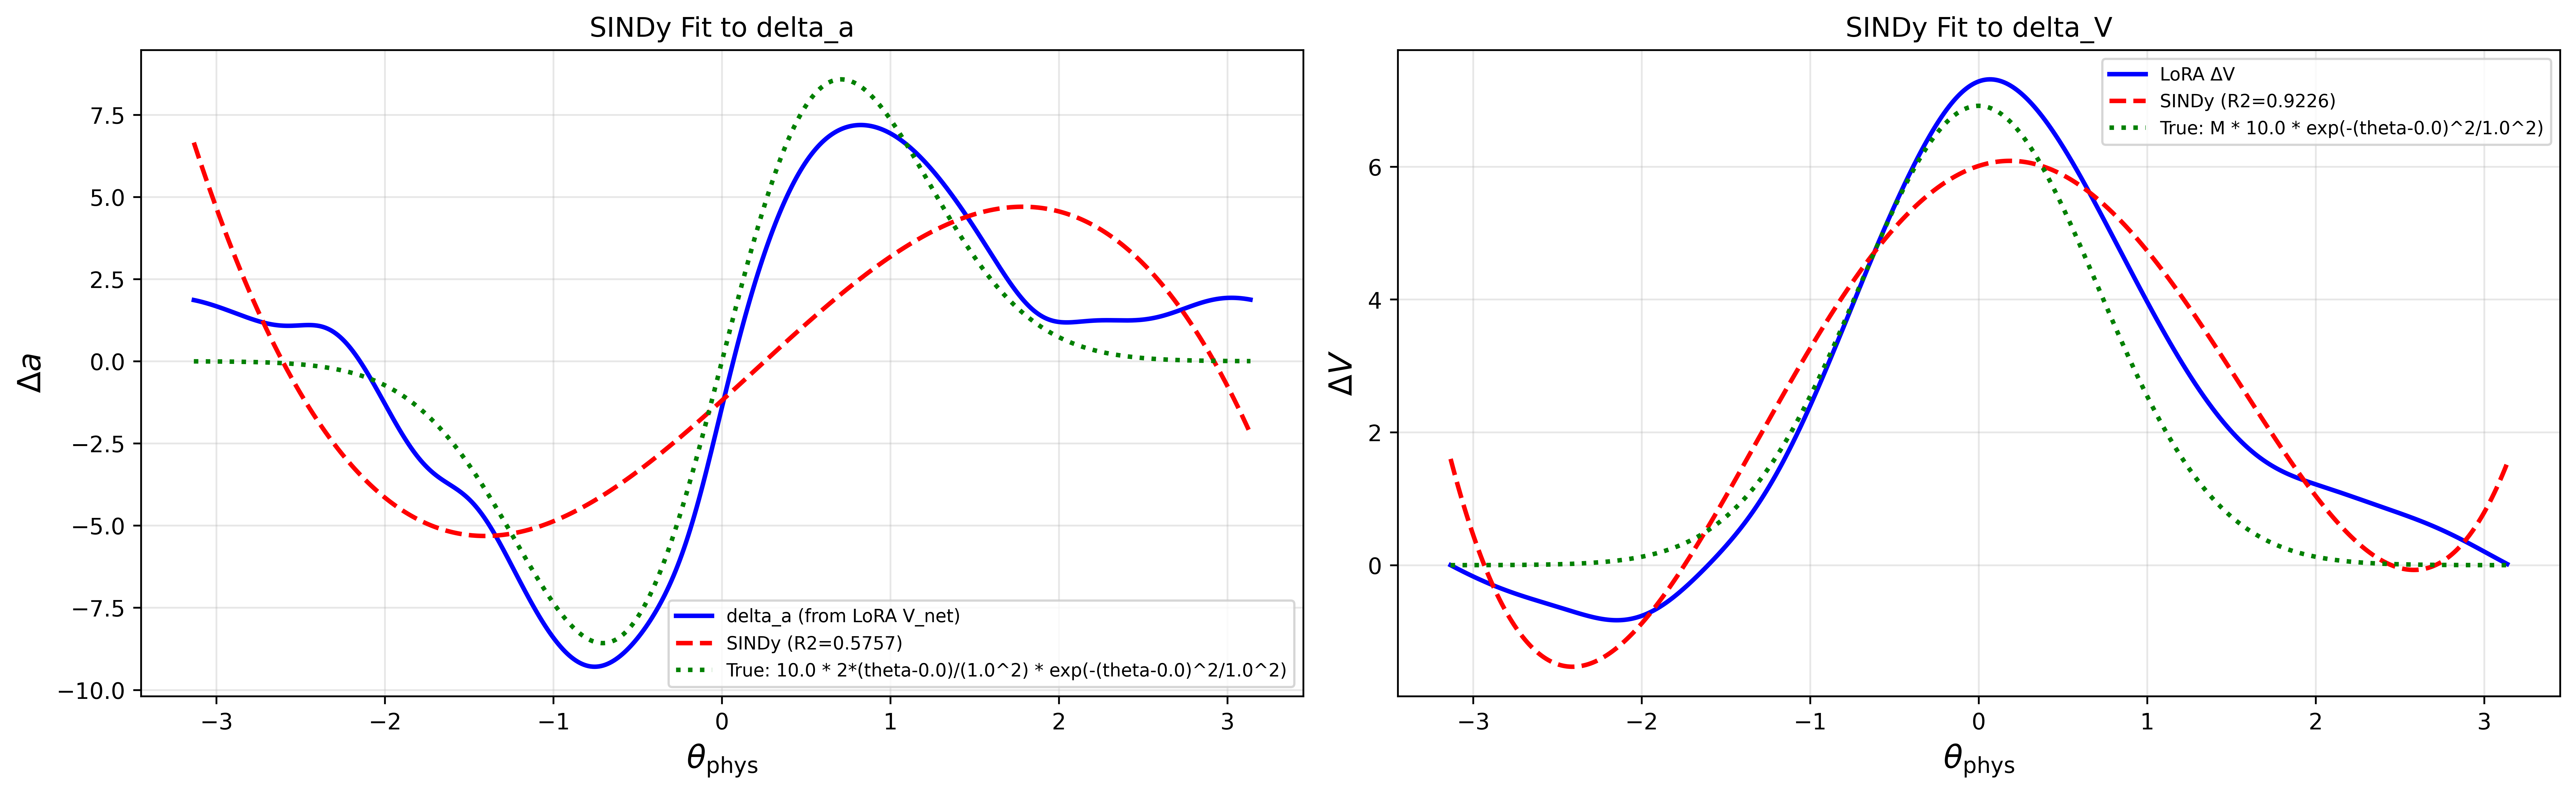

In [56]:
# Plot SINDy fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# da
sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
r2_sindy_da = best_da['r2']
ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from LoRA V_net)')
ax.plot(theta_gt, sindy_pred_da, 'r--', lw=2, label=f'SINDy (R2={r2_sindy_da:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('SINDy Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# dV
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
r2_sindy_dv = best_dv['r2']
ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='LoRA ΔV')
ax.plot(theta_gt, sindy_pred_dv, 'r--', lw=2, label=f'SINDy (R2={r2_sindy_dv:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('SINDy Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. PySR Symbolic Regression on Delta-V Signal

Apply PySR with polynomial operators to the clean delta_V_net signal.

In [57]:
print("=" * 60)
print(f"PySR — {PC['name']}")
print("=" * 60)

# --- PySR on delta_a ---
print(f"\n--- PySR on da ---")
X_pysr = theta_gt.reshape(-1, 1)

sr_da, idx_da, expr_da, pred_da = run_pysr(
    X_pysr, delta_acc_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    variable_name='theta',
)

PySR — Gaussian (eps=10.0, theta0=0.0, sigma=1.0)

--- PySR on da ---

Expressions evaluated per second: 2.720e+05
Progress: 532 / 3000 total iterations (17.733%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.869e+01  0.000e+00  y = theta
3           1.869e+01  5.067e-05  y = theta - 0.044102
5           1.869e+01  -0.000e+00  y = (theta + -0.043897) * 0.99715
6           1.582e+01  1.666e-01  y = exp((2.5575 - theta) * theta)
7           1.362e+01  1.497e-01  y = theta * (6.914 - (theta * theta))
8           1.391e+00  2.282e+00  y = theta * exp(3.0122 - (theta * theta))
10          1.191e+00  7.747e-02  y = theta * exp(3.0065 - (theta * (theta - -0.11862)))
12          6.507e-01  3.023e-01  y = ((theta + -0.12094) * exp(3.0026 - (theta * theta))) -...
                        

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 3.180e+05
Progress: 1860 / 3000 total iterations (62.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.869e+01  0.000e+00  y = theta
3           1.869e+01  5.067e-05  y = theta - 0.044102
5           1.869e+01  -0.000e+00  y = (theta + -0.043897) * 0.99715
6           1.582e+01  1.666e-01  y = exp((2.5575 - theta) * theta)
7           1.362e+01  1.497e-01  y = theta * (6.9155 - (theta * theta))
8           1.391e+00  2.282e+00  y = exp(3.0122 - (theta * theta)) * theta
10          9.116e-01  2.111e-01  y = exp(3.0122 - (theta * theta)) * (theta + -0.076307)
12          6.484e-01  1.703e-01  y = ((-0.1223 + theta) * exp(3.0121 - (theta * theta))) - ...
                                      -0.66131
14          3.695e-01  2.811e-01  y = (exp((

In [58]:
# --- PySR on delta_V ---
print(f"\n--- PySR on dV ---")

sr_dv, idx_dv, expr_dv, pred_dv = run_pysr(
    X_pysr, delta_V_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    variable_name='theta',
)


--- PySR on dV ---

Expressions evaluated per second: 2.580e+05


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


Progress: 474 / 3000 total iterations (15.800%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.906e+00  0.000e+00  y = 2.2477
5           3.549e+00  1.664e-01  y = 5.5411 - (theta * theta)
6           5.430e-01  1.877e+00  y = exp(2.0245 - (theta * theta))
8           3.138e-01  2.741e-01  y = exp((theta * (0.29745 - theta)) + 2.0123)
10          2.109e-01  1.987e-01  y = (theta * 0.31754) + exp(2.0245 - (theta * theta))
11          1.711e-01  2.095e-01  y = exp(((exp(theta) * 0.27564) - (theta * theta)) + 1.692...
                                      6)
13          1.400e-01  1.001e-01  y = exp((exp(theta) * 0.3563) - (((theta + 0.16368) * thet...
                                      a) + -1.6089))
14          1.100e-01  2.408e-01  y = exp(1.9862 - (theta * (theta + -0.19099)

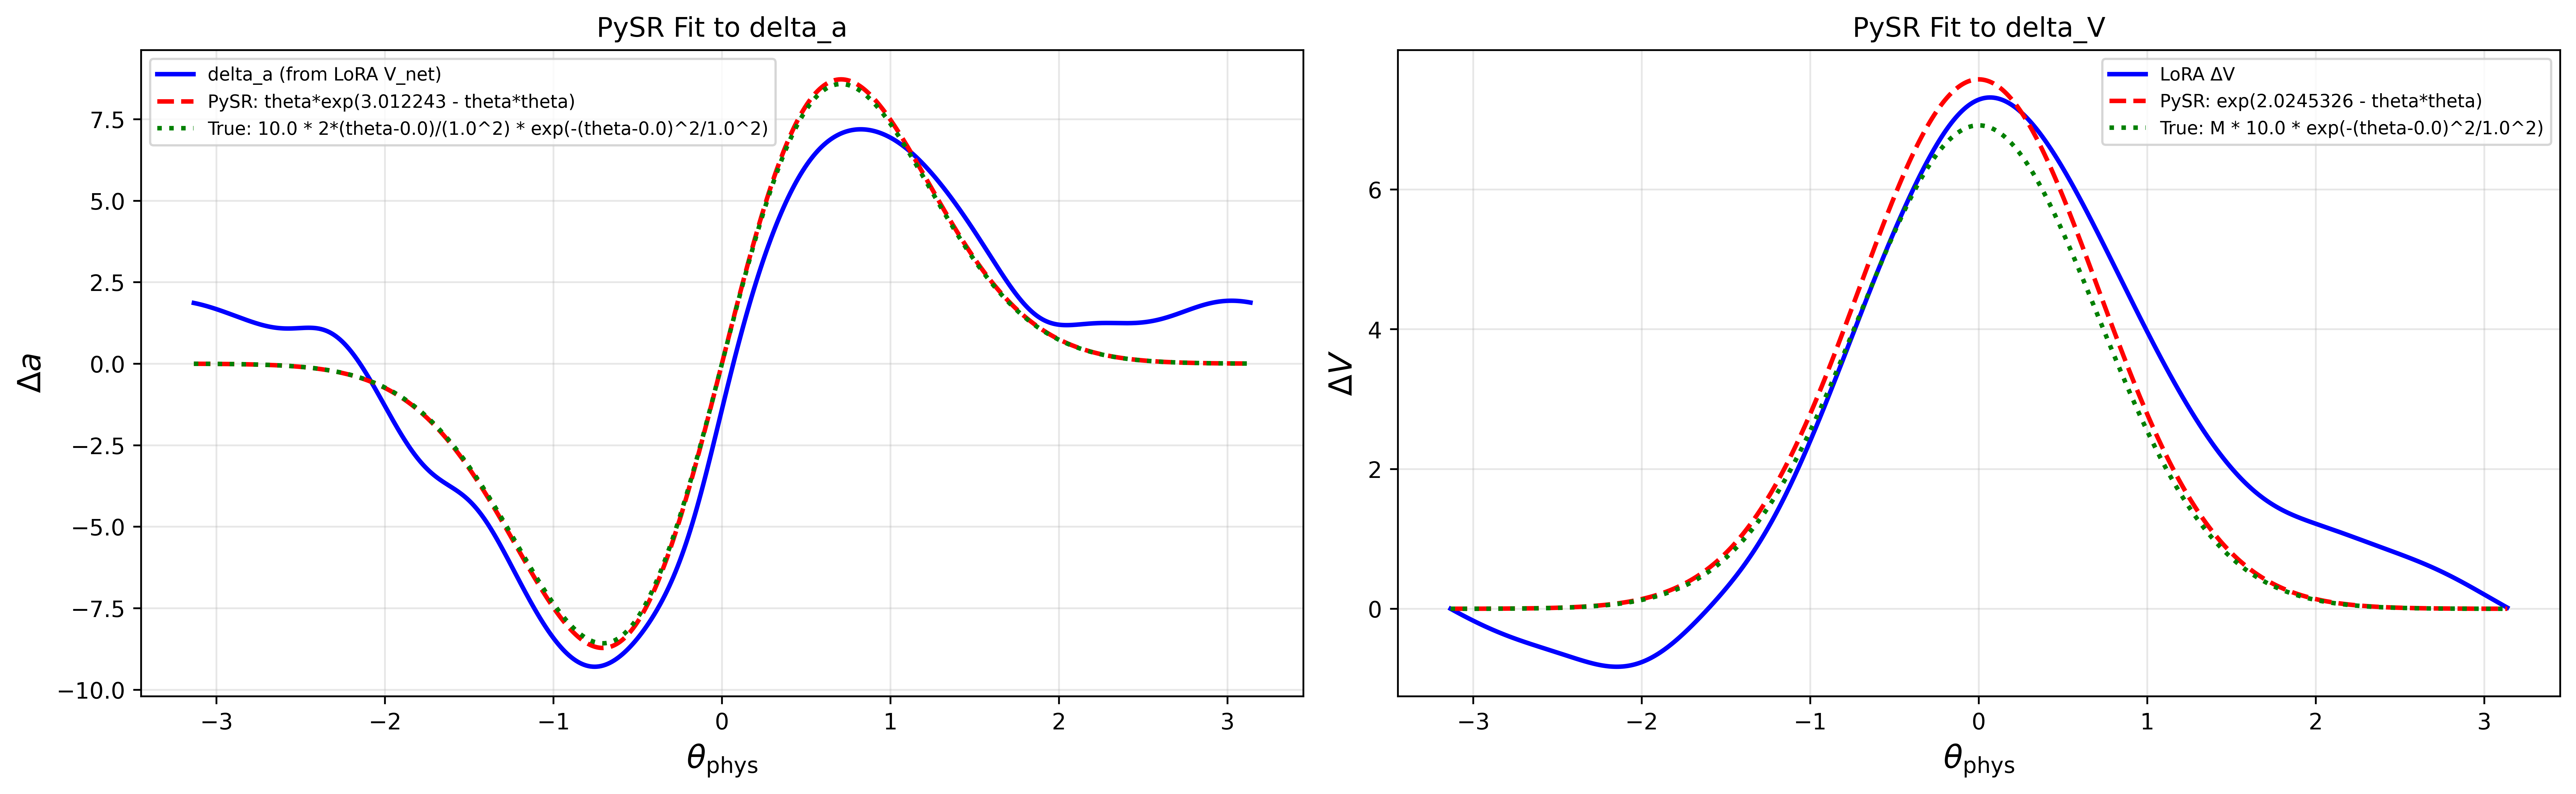

In [59]:
# Plot PySR fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from LoRA V_net)')
ax.plot(theta_gt, pred_da, 'r--', lw=2, label=f'PySR: {expr_da}')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('PySR Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='LoRA ΔV')
ax.plot(theta_gt, pred_dv, 'r--', lw=2, label=f'PySR: {expr_dv}')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('PySR Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Expand PySR Expressions to Polynomial Form

Extract polynomial coefficients from PySR expressions for direct comparison.

In [60]:
import sympy as sp

theta_sym = sp.Symbol('theta')

print("=" * 60)
print("PySR EXPRESSION ANALYSIS")
print("=" * 60)

print(f"\n  da best expression: {expr_da}")
print(f"  da expanded:        {sp.expand(expr_da)}")

print(f"\n  dV best expression: {expr_dv}")
print(f"  dV expanded:        {sp.expand(expr_dv)}")

# R2 of PySR predictions vs ground truth
from sklearn.metrics import r2_score
r2_pysr_da_vs_gt = r2_score(true_delta_a, pred_da)
r2_pysr_dv_vs_gt = r2_score(true_delta_V, pred_dv)
print(f"\n  R2(PySR da vs true da): {r2_pysr_da_vs_gt:.4f}")
print(f"  R2(PySR dV vs true dV): {r2_pysr_dv_vs_gt:.4f}")

# Full equation table
print(f"\n--- da equation table ---")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())
print(f"\n--- dV equation table ---")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

PySR EXPRESSION ANALYSIS

  da best expression: theta*exp(3.012243 - theta*theta)
  da expanded:        20.3329556349022*theta*exp(-theta**2)

  dV best expression: exp(2.0245326 - theta*theta)
  dV expanded:        7.57257069780146*exp(-theta**2)

  R2(PySR da vs true da): 0.9997
  R2(PySR dV vs true dV): 0.9850

--- da equation table ---
    complexity       loss                                                                                                                                  equation
0            1  18.693748                                                                                                                                     theta
1            3  18.691818                                                                                                                       theta - 0.044101935
2            5  18.691792                                                                                                         (theta + -0.043896575) * 0.997146
3 

## 9. Comparison: Delta-V Architecture vs Subtraction (Notebook 4)

Compare the coefficient recovery from this notebook (clean delta_V_net signal)
with notebook 4 (noisy V_pert − V_unpert subtraction).

**Notebook 4 results** (from polynomial regression):
- Δa θ³ coefficient: −0.319 (true: −0.338, ratio: 0.95)
- Δa θ² coefficient: +0.33 (true: −0.034, **wrong sign**)
- ΔV θ⁴ coefficient: +0.067 (true: +0.058, ratio: 1.15)

The key question: **does the clean delta_V_net signal improve lower-order term recovery?**

In [61]:
print("=" * 70)
print(f"  COMPARISON: Delta-V Architecture vs Subtraction Approach")
print(f"  Perturbation: {PC['name']}")
print("=" * 70)
print()
print("Run both NB5_2 and NB7_test2 with the same perturbation config")
print("and compare the R2 values and recovered expressions side by side.")
print()
print("This cell is a placeholder — fill in after running both notebooks.")

  COMPARISON: Delta-V Architecture vs Subtraction Approach
  Perturbation: Gaussian (eps=10.0, theta0=0.0, sigma=1.0)

Run both NB5_2 and NB7_test2 with the same perturbation config
and compare the R2 values and recovered expressions side by side.

This cell is a placeholder — fill in after running both notebooks.


## 10. Summary Report

In [62]:
from sklearn.metrics import r2_score

print("=" * 80)
print(f"     SUMMARY REPORT: {PC['name']}")
print("=" * 80)

print(f"\nPerturbation: {PC['name']}")
print(f"  True da = {PC['da_formula']}")
print(f"  True dV = {PC['dV_formula']}")

# ---- Signal quality ----
r2_nn_dv = r2_score(true_delta_V, delta_V_sorted)
r2_nn_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"\nNeural Network Signal Quality:")
print(f"  R2(delta_V_net vs true dV): {r2_nn_dv:.4f}")
print(f"  R2(delta_a vs true da):     {r2_nn_da:.4f}")

# ============================================================
# 1. Polynomial Regression
# ============================================================
print(f"\n{'='*80}")
print("  1. POLYNOMIAL REGRESSION")
print(f"{'='*80}")

deg_da = PC['poly_deg_da']
deg_dv = PC['poly_deg_dV']
c_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
c_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)

poly_da_pred = np.polyval(c_da, theta_gt)
poly_dv_pred = np.polyval(c_dv, theta_gt)
r2_poly_da = r2_score(delta_acc_sorted, poly_da_pred)
r2_poly_dv = r2_score(delta_V_sorted, poly_dv_pred)
r2_poly_da_gt = r2_score(true_delta_a, poly_da_pred)
r2_poly_dv_gt = r2_score(true_delta_V, poly_dv_pred)

print(f"\n  da (degree {deg_da}): R2 vs NN = {r2_poly_da:.4f}, R2 vs GT = {r2_poly_da_gt:.4f}")
print(f"  dV (degree {deg_dv}): R2 vs NN = {r2_poly_dv:.4f}, R2 vs GT = {r2_poly_dv_gt:.4f}")

# ============================================================
# 2. SINDy
# ============================================================
print(f"\n{'='*80}")
print("  2. SINDy")
print(f"{'='*80}")

sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
r2_sindy_da_gt = r2_score(true_delta_a, sindy_pred_da)
r2_sindy_dv_gt = r2_score(true_delta_V, sindy_pred_dv)

print(f"\n  da: {best_da['equations'][0]}")
print(f"      R2 vs NN = {best_da['r2']:.4f}, R2 vs GT = {r2_sindy_da_gt:.4f}")
print(f"      {best_da['n_active']} active terms, threshold = {best_da['threshold']:.4f}")
print(f"\n  dV: {best_dv['equations'][0]}")
print(f"      R2 vs NN = {best_dv['r2']:.4f}, R2 vs GT = {r2_sindy_dv_gt:.4f}")
print(f"      {best_dv['n_active']} active terms, threshold = {best_dv['threshold']:.4f}")

# ============================================================
# 3. PySR
# ============================================================
print(f"\n{'='*80}")
print("  3. PySR")
print(f"{'='*80}")

r2_pysr_da_nn = r2_score(delta_acc_sorted, pred_da)
r2_pysr_dv_nn = r2_score(delta_V_sorted, pred_dv)
r2_pysr_da_gt = r2_score(true_delta_a, pred_da)
r2_pysr_dv_gt = r2_score(true_delta_V, pred_dv)

print(f"\n  da: {expr_da}")
print(f"      R2 vs NN = {r2_pysr_da_nn:.4f}, R2 vs GT = {r2_pysr_da_gt:.4f}")
print(f"\n  dV: {expr_dv}")
print(f"      R2 vs NN = {r2_pysr_dv_nn:.4f}, R2 vs GT = {r2_pysr_dv_gt:.4f}")

# ============================================================
# Comparison Table
# ============================================================
print(f"\n{'='*80}")
print("  METHOD COMPARISON")
print(f"{'='*80}")

print(f"\n  {'Method':<20} {'R2(da vs GT)':>14} {'R2(dV vs GT)':>14}")
print(f"  {'-'*50}")
print(f"  {'NN (raw signal)':<20} {r2_nn_da:>14.4f} {r2_nn_dv:>14.4f}")
print(f"  {'Poly Regression':<20} {r2_poly_da_gt:>14.4f} {r2_poly_dv_gt:>14.4f}")
print(f"  {'SINDy':<20} {r2_sindy_da_gt:>14.4f} {r2_sindy_dv_gt:>14.4f}")
print(f"  {'PySR':<20} {r2_pysr_da_gt:>14.4f} {r2_pysr_dv_gt:>14.4f}")

print(f"\n{'='*80}")

     SUMMARY REPORT: Gaussian (eps=10.0, theta0=0.0, sigma=1.0)

Perturbation: Gaussian (eps=10.0, theta0=0.0, sigma=1.0)
  True da = 10.0 * 2*(theta-0.0)/(1.0^2) * exp(-(theta-0.0)^2/1.0^2)
  True dV = M * 10.0 * exp(-(theta-0.0)^2/1.0^2)

Neural Network Signal Quality:
  R2(delta_V_net vs true dV): 0.8902
  R2(delta_a vs true da):     0.9299

  1. POLYNOMIAL REGRESSION

  da (degree 5): R2 vs NN = 0.8683, R2 vs GT = 0.7367
  dV (degree 6): R2 vs NN = 0.9876, R2 vs GT = 0.8667

  2. SINDy

  da: -1.195 1 + 4.641 theta + 0.350 theta^2 + -0.616 theta^3
      R2 vs NN = 0.5757, R2 vs GT = 0.4166
      4 active terms, threshold = 0.2336

  dV: 6.010 1 + 0.819 theta + -2.189 theta^2 + -0.085 theta^3 + 0.177 theta^4
      R2 vs NN = 0.9226, R2 vs GT = 0.7749
      5 active terms, threshold = 0.0379

  3. PySR

  da: theta*exp(3.012243 - theta*theta)
      R2 vs NN = 0.9367, R2 vs GT = 0.9997

  dV: exp(2.0245326 - theta*theta)
      R2 vs NN = 0.9214, R2 vs GT = 0.9850

  METHOD COMPARISON
